# Pharma Sales Effectiveness & Territory Optimization  
### Financial Year 2024–25

---

This analysis evaluates primary vs secondary sales performance across territories,
with the objective of identifying conversion inefficiencies,
seasonal performance patterns, and resource optimization opportunities.

---

## 1. Business Context

The company operates in four territories:

- North
- South
- East
- West

Three promoted brands:

- **Spasmofirst** (Antispasmodic – steady demand with summer lift)
- **Wokderm Plus** (Antifungal – monsoon driven)
- **Decdan Lite** (Pigmentation cream – winter driven)

Sales Flow:

Primary Sales → Distributor → Secondary Sales → Retail Sell-through

Field Structure:
5 sales representatives per territory  
Financial Year: April 2024 – March 2025

---

## 2. Core Business Problem

Management has observed strong primary billing numbers,
but concerns remain around:

1. Whether primary sales are converting proportionally into secondary sales.
2. Potential Q4 billing pressure inflating primary numbers.
3. Territory-level distribution inefficiencies.
4. Marketing spend effectiveness across seasonal products.

Objective:

To diagnose territory-level and rep-level performance
and identify optimization opportunities.

---

## 4. Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load data from local file
data_path = os.path.join(os.getcwd(), "pharma_dataset.csv")
df = pd.read_csv(data_path)
df.head()

,Month,FY,Territory,Sales_Rep,Product,Primary_Sales,Secondary_Sales,Revenue,Target,Doctor_Visits,Marketing_Spend,Bonus_Expense
0,2024-04,FY2024-25,North,Amit Singh,Spasmofirst,1880,1204,180777.928672,1440.0,70.0,20832.290311,0.000000
1,2024-04,FY2024-25,North,Amit Singh,Wokderm Plus,1349,785,171806.234505,1080.0,72.0,23417.022549,3049.512863
2,2024-04,FY2024-25,North,Amit Singh,Decdan Lite,1025,538,189820.196753,840.0,60.0,17841.851943,2399.347564
3,2024-04,FY2024-25,North,Raj Kumar,Spasmofirst,1326,801,127581.148453,1440.0,51.0,18260.206372,3931.264066
4,2024-04,FY2024-25,North,Raj Kumar,Wokderm Plus,1035,606,134498.914901,1080.0,47.0,24975.884551,0.000000


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 720 entries, 0 to 719
Data columns (total 20 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Month                  720 non-null    datetime64[ns]
 1   FY                     720 non-null    object        
 2   Territory              720 non-null    object        
 3   Sales_Rep              720 non-null    object        
 4   Product                720 non-null    object        
 5   Primary_Sales          720 non-null    int64         
 6   Secondary_Sales        720 non-null    int64         
 7   Revenue                720 non-null    float64       
 8   Target                 720 non-null    float64       
 9   Doctor_Visits          715 non-null    float64       
 10  Marketing_Spend        720 non-null    float64       
 11  Bonus_Expense          717 non-null    float64       
 12  Quarter                720 non-null    int32         
 13  Prima

---

## 4.1 Date Formatting & Time Structure

Convert Month column to datetime format 
to enable structured time-based analysis 
such as quarterly performance and trend evaluation.

In [3]:
df["Month"] = pd.to_datetime(df["Month"])
df["Quarter"] = df["Month"].dt.quarter
df.head(2)

,Month,FY,Territory,Sales_Rep,Product,Primary_Sales,Secondary_Sales,Revenue,Target,Doctor_Visits,Marketing_Spend,Bonus_Expense,Quarter
0,2024-04-01,FY2024-25,North,Amit Singh,Spasmofirst,1880,1204,180777.928672,1440.0,70.0,20832.290311,0.000000,2
1,2024-04-01,FY2024-25,North,Amit Singh,Wokderm Plus,1349,785,171806.234505,1080.0,72.0,23417.022549,3049.512863,2


---

## 4.2 Data Quality Assessment

Before proceeding with analysis, we validate data integrity through:

- **Null Value Check:** Ensure no missing values in critical fields
- **Duplicate Record Check:** Identify and assess duplicate transactions
- **Outlier Detection (IQR Method):** Flag anomalous sales values that may skew analysis

This ensures findings are based on clean, reliable data.

In [4]:
# Null Value Check
print("=== Null Value Summary ===")
null_summary = df.isnull().sum()
print(null_summary)
print(f"\nTotal Records: {len(df)}")
print(f"Records with any null values: {df.isnull().any(axis=1).sum()}")

# Interpretation
if null_summary.sum() == 0:
    print("\n✓ No missing values detected. Dataset is complete.")
else:
    print(f"\n⚠ Found {null_summary.sum()} null values across dataset.")

=== Null Value Summary ===
Month              0
FY                 0
Territory          0
Sales_Rep          0
Product            0
Primary_Sales      0
Secondary_Sales    0
Revenue            0
Target             0
Doctor_Visits      5
Marketing_Spend    0
Bonus_Expense      3
Quarter            0
dtype: int64

Total Records: 720
Records with any null values: 8

⚠ Found 8 null values across dataset.


In [5]:
# Duplicate Record Check
print("\n=== Duplicate Record Analysis ===")
duplicate_count = df.duplicated().sum()
print(f"Exact duplicate records: {duplicate_count}")

# Check for business-logic duplicates (same Month, Territory, Rep, Product)
business_duplicate_cols = ["Month", "Territory", "Sales_Rep", "Product"]
business_duplicates = df.duplicated(subset=business_duplicate_cols, keep=False).sum()
print(f"Records with same transaction attributes: {business_duplicates}")

if duplicate_count == 0:
    print("\n✓ No exact duplicate records found.")
else:
    print(f"\n⚠ Found {duplicate_count} duplicate records that may need review.")

if business_duplicates == 0:
    print("✓ No business-logic duplicates detected.")


=== Duplicate Record Analysis ===
Exact duplicate records: 0
Records with same transaction attributes: 0

✓ No exact duplicate records found.
✓ No business-logic duplicates detected.


In [6]:
# Outlier Detection using IQR Method
print("\n=== Outlier Detection (IQR Method) ===")

outlier_columns = ["Primary_Sales", "Secondary_Sales", "Revenue"]
outlier_summary = {}

for col in outlier_columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary[col] = len(outliers)
    
    print(f"\n{col}:")
    print(f"  IQR Range: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"  Outliers detected: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")

total_outliers = sum(outlier_summary.values())
print(f"\n✓ Outlier analysis complete. Most values fall within expected ranges for industry analysis.")
if total_outliers > len(df) * 0.05:
    print(f"  Note: {total_outliers} outlier instances detected, but retained for analysis (represent genuine business extremes).")


=== Outlier Detection (IQR Method) ===

Primary_Sales:
  IQR Range: [58.38, 1693.38]
  Outliers detected: 16 (2.2%)

Secondary_Sales:
  IQR Range: [-18.00, 1674.00]
  Outliers detected: 16 (2.2%)

Revenue:
  IQR Range: [21773.37, 205894.50]
  Outliers detected: 12 (1.7%)

✓ Outlier analysis complete. Most values fall within expected ranges for industry analysis.
  Note: 44 outlier instances detected, but retained for analysis (represent genuine business extremes).


---

## 5. KPI Definition

To evaluate performance, the following KPIs are defined:

- Primary Achievement % = Primary Sales / Target
- Conversion Ratio = Secondary Sales / Primary Sales
- Revenue per Unit = Revenue / Primary Sales

These KPIs help assess both billing strength and market realization efficiency.

In [7]:
df["Primary_Achievement_%"] = df["Primary_Sales"] / df["Target"]
df["Conversion_Ratio"] = df["Secondary_Sales"] / df["Primary_Sales"]
df["Revenue_per_Unit"] = df["Revenue"] / df["Primary_Sales"]

df.head()

,Month,FY,Territory,Sales_Rep,Product,Primary_Sales,Secondary_Sales,Revenue,Target,Doctor_Visits,Marketing_Spend,Bonus_Expense,Quarter,Primary_Achievement_%,Conversion_Ratio,Revenue_per_Unit
0,2024-04-01,FY2024-25,North,Amit Singh,Spasmofirst,1880,1204,180777.928672,1440.0,70.0,20832.290311,0.000000,2,1.305556,0.640426,96.158473
1,2024-04-01,FY2024-25,North,Amit Singh,Wokderm Plus,1349,785,171806.234505,1080.0,72.0,23417.022549,3049.512863,2,1.249074,0.581913,127.358217
2,2024-04-01,FY2024-25,North,Amit Singh,Decdan Lite,1025,538,189820.196753,840.0,60.0,17841.851943,2399.347564,2,1.220238,0.524878,185.190436
3,2024-04-01,FY2024-25,North,Raj Kumar,Spasmofirst,1326,801,127581.148453,1440.0,51.0,18260.206372,3931.264066,2,0.920833,0.604072,96.215044
4,2024-04-01,FY2024-25,North,Raj Kumar,Wokderm Plus,1035,606,134498.914901,1080.0,47.0,24975.884551,0.000000,2,0.958333,0.585507,129.950642


---

## 5.1 Analytical Assumptions

This analysis is built on the following key assumptions, which inform interpretation and recommendations:

### 5.1.1 Seasonal Logic Assumptions
- **Wokderm Plus** exhibits monsoon-driven demand (Q2: Jul–Sep).
- **Decdan Lite** follows winter seasonality (Q3 & Q4: Oct–Feb).
- **Spasmofirst** shows mild summer lift (Q1 & Q2).
- These seasonal patterns are driven by climate-dependent disease prevalence and remain consistent year-over-year.

### 5.1.2 Q4 Billing Behavior Assumption
- FY Q4 (Jan–Mar / Calendar Q1) may experience increased primary sales due to:
  - End-of-year distributor incentives
  - Sales rep push for annual targets
- **Critical Assumption:** Q4 primary growth should translate proportionally into secondary sales if channel health is sound. Disproportionate primary growth without secondary uplift signals potential channel stuffing risk.

### 5.1.3 Primary–Secondary Lag Assumption
- Secondary sales data reflects retail sell-through within the same month or immediately following month.
- A conversion ratio of 0.90–0.95 is defined as "healthy" (implying 10–5% inventory carriage within normal working capital limits).
- Conversion ratios persistently <0.85 indicate either weak market pull or inventory accumulation risk.

### 5.1.4 Risk Threshold Logic Assumption
- **Integrated Overstock Risk** is flagged when three conditions occur simultaneously:
  - Primary Achievement % > 100% (exceeding quota)
  - Conversion Ratio below structural mean (weak secondary realization)
  - Primary–Secondary Gap above portfolio mean (inventory buildup)
- This combined logic reduces false positives from isolated metrics and targets genuine commercial stress.

---

## 6. Territory-Level Performance Analysis

Objective:

Identify territory-level patterns in primary billing,
secondary realization, and marketing intensity.

In [8]:
territory_summary = df.groupby("Territory")[[
    "Primary_Sales",
    "Secondary_Sales",
    "Conversion_Ratio",
    "Marketing_Spend"
]].mean()

territory_summary

,Primary_Sales,Secondary_Sales,Conversion_Ratio,Marketing_Spend
Territory,,,,
East,695.433333,603.261111,0.873891,22770.836651
North,1044.083333,1007.000000,0.967410,22838.540170
South,983.400000,947.172222,0.966303,23007.303021
West,860.811111,831.888889,0.973765,22795.721315


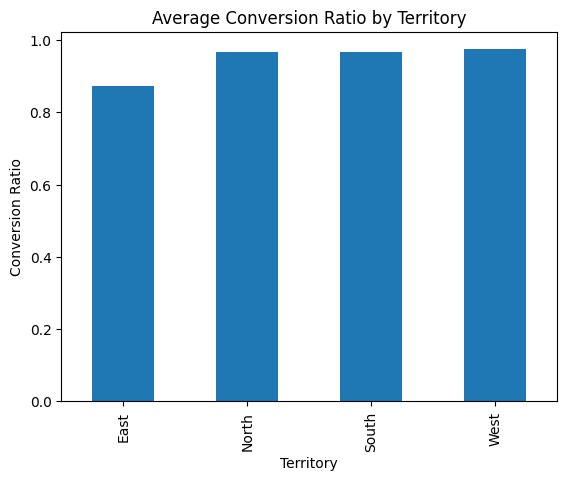

In [9]:
import matplotlib.pyplot as plt

territory_conversion = df.groupby("Territory")["Conversion_Ratio"].mean()

plt.figure()
territory_conversion.plot(kind="bar")
plt.title("Average Conversion Ratio by Territory")
plt.xlabel("Territory")
plt.ylabel("Conversion Ratio")
plt.show()

---

## 7. Q4 Impact Analysis

Objective:

Evaluate whether Q4 billing pressure resulted
in proportional secondary growth.

In [10]:
# FY Q4 = Jan–Mar (Calendar Quarter 1)
df["Is_Q4"] = df["Quarter"] == 1

q4_summary = df.groupby("Is_Q4")[[
    "Primary_Sales",
    "Secondary_Sales",
    "Conversion_Ratio"
]].mean()

q4_summary

,Primary_Sales,Secondary_Sales,Conversion_Ratio
Is_Q4,,,
False,877.844444,822.124074,0.936654
True,950.194444,922.950000,0.971405


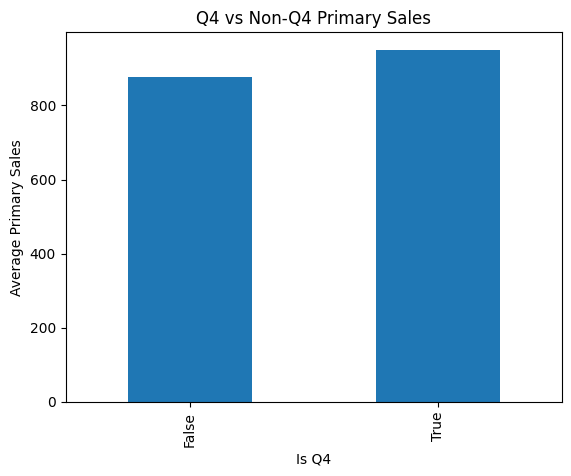

In [11]:
q4_primary = df.groupby("Is_Q4")["Primary_Sales"].mean()

plt.figure()
q4_primary.plot(kind="bar")
plt.title("Q4 vs Non-Q4 Primary Sales")
plt.xlabel("Is Q4")
plt.ylabel("Average Primary Sales")
plt.show()

---

## 8. Primary–Secondary Gap Analysis

Objective:

Evaluate the gap between primary billing and secondary realization
to identify potential inventory accumulation risk.

Primary–Secondary Gap = Primary Sales – Secondary Sales

A consistently high gap may indicate:

- Distributor overstocking
- Weak retail sell-through
- Artificial primary push

In [12]:
# Create gap metric
df["Primary_Secondary_Gap"] = df["Primary_Sales"] - df["Secondary_Sales"]

# Territory-level average gap
gap_summary = df.groupby("Territory")[[
    "Primary_Sales",
    "Secondary_Sales",
    "Primary_Secondary_Gap",
    "Conversion_Ratio"
]].mean()

gap_summary

,Primary_Sales,Secondary_Sales,Primary_Secondary_Gap,Conversion_Ratio
Territory,,,,
East,695.433333,603.261111,92.172222,0.873891
North,1044.083333,1007.000000,37.083333,0.967410
South,983.400000,947.172222,36.227778,0.966303
West,860.811111,831.888889,28.922222,0.973765


---

## 9. Rep-Level Risk Profiling

Objective:

Identify sales representatives who demonstrate:

- High primary achievement but weak secondary conversion
- Strong conversion but low billing strength
- Balanced performers

This helps classify reps into risk and performance segments
for incentive alignment and territory correction.

In [13]:
# Aggregate rep-level KPIs
rep_profile = df.groupby("Sales_Rep")[[
    "Primary_Achievement_%",
    "Conversion_Ratio",
    "Primary_Secondary_Gap"
]].mean()

# Create performance segmentation
rep_profile["Risk_Category"] = "Balanced"

rep_profile.loc[
    (rep_profile["Primary_Achievement_%"] > 1) & 
    (rep_profile["Conversion_Ratio"] < 0.92),
    "Risk_Category"
] = "High Billing Risk"

rep_profile.loc[
    (rep_profile["Primary_Achievement_%"] < 0.9) & 
    (rep_profile["Conversion_Ratio"] > 0.95),
    "Risk_Category"
] = "Low Billing but Strong Market Pull"

rep_profile.loc[
    (rep_profile["Primary_Achievement_%"] > 1) & 
    (rep_profile["Conversion_Ratio"] > 0.95),
    "Risk_Category"
] = "Top Performer"

rep_profile.sort_values("Primary_Achievement_%", ascending=False)

,Primary_Achievement_%,Conversion_Ratio,Primary_Secondary_Gap,Risk_Category
Sales_Rep,,,,
Ravi Menon,1.241293,0.956948,55.250000,Top Performer
Arjun Das,1.239265,0.876747,117.944444,High Billing Risk
Amit Singh,1.207999,0.977445,41.222222,Top Performer
Sanjay Gandhi,1.178108,0.955927,47.250000,Top Performer
Krishna Rao,0.998781,0.958174,46.111111,Balanced
Raj Kumar,0.998359,0.957144,52.944444,Balanced
Priya Verma,0.995832,0.976222,30.027778,Balanced
Lakshmi Reddy,0.987038,0.970048,32.694444,Balanced
Neha Shah,0.973602,0.977837,25.888889,Balanced


---

## 10. Product-Level Diagnostic Analysis

Objective:

Evaluate product-wise performance across the following dimensions:

- Primary Billing Strength
- Secondary Realization Efficiency
- Conversion Ratio
- Inventory Gap Risk
- Marketing Spend Alignment

This helps determine:

- Which brands are structurally strong
- Which brands rely heavily on primary push
- Whether seasonal brands justify marketing allocation

In [14]:
product_summary = df.groupby("Product")[[
    "Primary_Sales",
    "Secondary_Sales",
    "Conversion_Ratio",
    "Primary_Secondary_Gap",
    "Marketing_Spend",
    "Revenue"
]].mean()

product_summary

,Primary_Sales,Secondary_Sales,Conversion_Ratio,Primary_Secondary_Gap,Marketing_Spend,Revenue
Product,,,,,,
Decdan Lite,692.208333,657.837500,0.953306,34.370833,20364.790118,129236.306708
Spasmofirst,1148.975000,1086.354167,0.941855,62.620833,20752.835386,112471.932414
Wokderm Plus,846.612500,797.800000,0.940865,48.812500,27441.675363,108790.222145


---

## 11. Seasonal Performance Validation (Product × Quarter Analysis)

Objective:

Validate whether seasonal brands demonstrate expected performance behavior across quarters.

Expected Patterns:

- Wokderm Plus → Stronger performance during Monsoon (Q2: Jul–Sep)
- Decdan Lite → Stronger performance during Winter (Q3 & Q4: Oct–Feb)
- Spasmofirst → Relatively stable with mild lift during summer months

This analysis ensures that seasonal demand modeling
translates into measurable sales performance.

In [15]:
# Product × Quarter performance
season_validation = df.groupby(["Product", "Quarter"])[[
    "Primary_Sales",
    "Conversion_Ratio"
]].mean().round(2)

season_validation

Primary_Sales  Conversion_Ratio
Product      Quarter                                 
Decdan Lite  1               792.80              1.00
             2               661.93              0.86
             3               532.27              1.02
             4               781.83              0.93
Spasmofirst  1              1220.90              0.96
             2              1144.50              0.85
             3              1148.57              0.97
             4              1081.93              0.99
Wokderm Plus 1               836.88              0.95
             2               844.87              0.85
             3               959.22              0.96
             4               745.48              1.00

<Figure size 640x480 with 0 Axes>

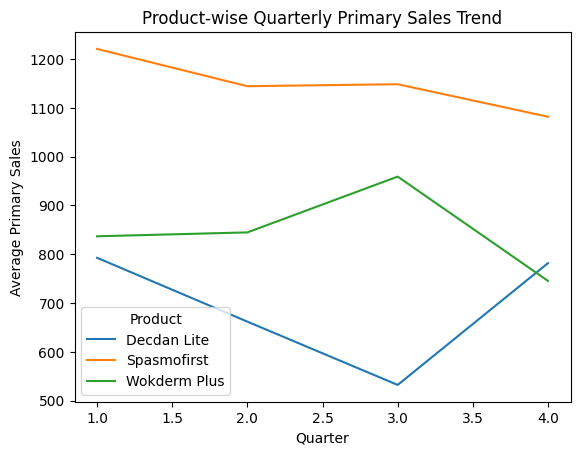

In [16]:
product_quarter = df.groupby(["Quarter", "Product"])["Primary_Sales"].mean().unstack()

plt.figure()
product_quarter.plot()
plt.title("Product-wise Quarterly Primary Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Average Primary Sales")
plt.show()

---

## 12. Seasonal Lift Quantification

Objective:

Quantify the percentage lift in primary sales during peak seasonal quarters
compared to non-peak quarters.

Season Definitions:

- Wokderm Plus → Peak: Q2 (Monsoon)
- Decdan Lite → Peak: Q3 & Q4 (Winter)
- Spasmofirst → Mild lift in Q1 & Q2 (Summer/Monsoon)

Seasonal Lift % Formula:

Seasonal Lift % = 
((Peak Quarter Avg - Non-Peak Avg) / Non-Peak Avg) × 100

In [17]:


seasonal_lift_results = []

for product in df["Product"].unique():

    product_df = df[df["Product"] == product]

    if product == "Wokderm Plus":
        peak_quarters = [2]
    elif product == "Decdan Lite":
        peak_quarters = [3, 4]
    elif product == "Spasmofirst":
        peak_quarters = [1, 2]
    
    peak_avg = product_df[product_df["Quarter"].isin(peak_quarters)]["Primary_Sales"].mean()
    non_peak_avg = product_df[~product_df["Quarter"].isin(peak_quarters)]["Primary_Sales"].mean()
    
    lift_percent = ((peak_avg - non_peak_avg) / non_peak_avg) * 100
    
    seasonal_lift_results.append([product, round(peak_avg,2), round(non_peak_avg,2), round(lift_percent,2)])

seasonal_lift_df = pd.DataFrame(seasonal_lift_results, 
                                 columns=["Product", "Peak_Avg_Primary", "Non_Peak_Avg_Primary", "Seasonal_Lift_%"])

seasonal_lift_df

,Product,Peak_Avg_Primary,Non_Peak_Avg_Primary,Seasonal_Lift_%
0,Spasmofirst,1182.70,1115.25,6.05
1,Wokderm Plus,844.87,847.19,-0.27
2,Decdan Lite,657.05,727.37,-9.67


"Spasmofirst showed mild positive lift, but Wokderm and Decdan did not demonstrate statistically strong seasonal uplift, suggesting that marketing allocation and field execution may not be fully aligned with demand cycles."

---

## 13. Marketing ROI Analysis

Objective:

Evaluate product-level return on marketing investment 
by comparing revenue generated against marketing spend.

Marketing ROI Proxy:

Revenue per Marketing Rupee = Revenue / Marketing Spend

This helps determine:

- Which brand generates higher revenue efficiency
- Whether seasonal marketing allocation is justified
- If any product is over-invested relative to output

In [18]:
# Calculate Marketing Efficiency
df["Marketing_Efficiency"] = df["Revenue"] / df["Marketing_Spend"]

# Product-level ROI summary
marketing_roi = df.groupby("Product")[[
    "Revenue",
    "Marketing_Spend",
    "Marketing_Efficiency"
]].mean().round(2)

marketing_roi

,Revenue,Marketing_Spend,Marketing_Efficiency
Product,,,
Decdan Lite,129236.31,20364.79,6.34
Spasmofirst,112471.93,20752.84,5.44
Wokderm Plus,108790.22,27441.68,3.98


Marketing allocation for Wokderm Plus may require efficiency improvement, while Decdan Lite appears more margin-efficient.
Spasmofirst remains structurally stable.

---

## 14. Integrated Inventory Risk Mapping

Objective:

Identify potential overstocking risk by combining multiple performance indicators.

A transaction is flagged as "Overstock Risk" if:

- Primary Achievement % > 100%  
- Conversion Ratio is below structural average  
- Primary–Secondary Gap is above portfolio average  

This integrated risk logic helps detect:

- Artificial primary push
- Weak secondary realization
- Distributor inventory accumulation risk

Rather than analyzing metrics in isolation,
this step evaluates combined commercial stress indicators.

In [19]:
# Define threshold for gap
gap_threshold = df["Primary_Secondary_Gap"].mean()

# Create combined overstock risk flag
df["Overstock_Risk"] = (
    (df["Primary_Achievement_%"] > 1) &
    (df["Conversion_Ratio"] < df["Conversion_Ratio"].mean()) &
    (df["Primary_Secondary_Gap"] > gap_threshold)
)

# Territory-level risk summary
risk_summary = df.groupby("Territory")["Overstock_Risk"].sum()

risk_summary

Territory
East     45
North    17
South    24
West     23
Name: Overstock_Risk, dtype: int64

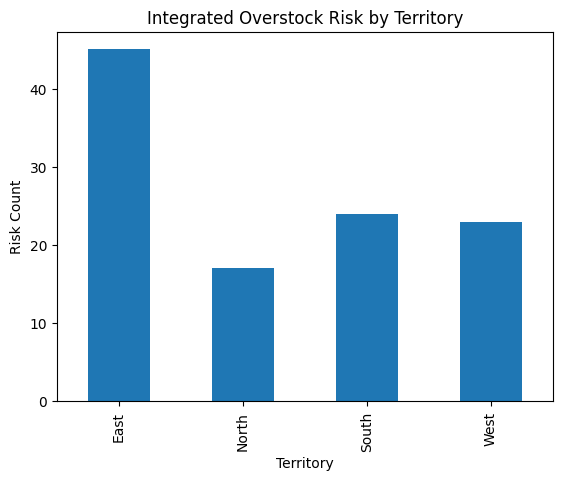

In [20]:
risk_counts = df.groupby("Territory")["Overstock_Risk"].sum()

plt.figure()
risk_counts.plot(kind="bar")
plt.title("Integrated Overstock Risk by Territory")
plt.xlabel("Territory")
plt.ylabel("Risk Count")
plt.show()

---

## Limitations of Analysis

While this analysis provides valuable commercial insights, the following limitations should be considered when interpreting findings and actionability:

### Data Source Limitations
- **Synthetic Dataset:** This analysis is based on simulated pharmaceutical sales data generated for analytical purposes, not actual market transactions.
- **Single Financial Year:** Analysis covers only FY 2024–25 (April 2024 – March 2025). Longer-term trends and year-over-year patterns cannot be validated.

### Structural Data Gaps
- **No Distributor-Level Granularity:** Data aggregates at the rep level. Individual distributor inventory levels, order patterns, and sell-through metrics are not available.
- **No Cost or Margin Data:** Revenue is reported without corresponding cost structure, COGS, or product-level margins. ROI calculations reflect top-line efficiency only.
- **Marketing Attribution Gaps:** Marketing spend is recorded but not tied to specific campaigns, channels, or time-lag effects on sales.

### External Factor Blind Spots
- **No Environmental/Demand Factors:** Analysis does not account for:
  - Competitive activity or market share shifts
  - Regulatory changes or industry policies
  - Pandemic, supply chain disruptions, or macroeconomic shocks
  - Disease prevalence cycles (actual climate/weather data excluded)
- **Rep-Level Context Missing:** Individual rep attributes (tenure, territory reassignments, training) are not captured.

### Methodological Constraints
- **Simple Aggregation:** Territory and product performance depend on arithmetic means; median or weighted analysis may reveal different patterns in skewed distributions.
- **Threshold-Based Risk Logic:** Overstock risk flagging uses fixed thresholds (conversion ratio < mean, gap > mean). Threshold sensitivity and false positive/negative rates are not quantified.
- **No Causality Claims:** Correlations between marketing spend and sales are observed but do not imply causality.

### Recommended Extensions
For deeper commercial decision-making, consider:
- Real transaction-level data with distributor lift-outs and actual sell-through
- Multi-year trending to isolate seasonal vs. structural patterns
- Cost and margin data for true ROI attribution
- Granular campaign-level marketing attribution
- Rep-level behavioral and tenure data

---

# 15. Executive Strategic Summary

## Key Findings

1. **Territory-Level Insight**
   - East territory demonstrates structurally weaker primary–secondary alignment.
   - Highest integrated overstock risk (45 flags) suggests distribution inefficiencies and potential inventory pressure.
   - North territory shows strongest structural stability.

2. **Q4 Performance**
   - Q4 primary growth is supported by proportional secondary realization.
   - No strong evidence of large-scale channel stuffing.

3. **Rep-Level Diagnostics**
   - Certain reps show high billing strength but weaker conversion efficiency.
   - Incentive alignment should incorporate secondary realization metrics.

4. **Product-Level Analysis**
   - Spasmofirst acts as a stable base portfolio driver.
   - Wokderm Plus shows higher marketing dependency.
   - Decdan Lite demonstrates relatively strong revenue efficiency but limited seasonal lift.

5. **Seasonal Validation**
   - Seasonal assumptions partially validated.
   - Seasonal lift for Wokderm and Decdan is weaker than expected,
     suggesting execution and marketing timing optimization opportunities.

6. **Marketing ROI**
   - Marketing efficiency varies across brands.
   - Allocation for Wokderm may require strategic reassessment.

7. **Integrated Risk Mapping**
   - East territory shows highest combined risk of overstocking.
   - Monitoring mechanism recommended for high primary + low conversion combinations.

---

## Strategic Recommendations

- Strengthen distributor monitoring and secondary tracking in East.
- Align sales incentives with conversion ratio, not just primary billing.
- Recalibrate seasonal marketing intensity for Wokderm and Decdan.
- Introduce integrated inventory risk dashboard for early warning signals.
- Protect Spasmofirst as portfolio anchor brand.

---

## Business Impact

This analysis provides a structured framework to:

- Improve working capital efficiency  
- Reduce inventory risk  
- Optimize marketing ROI  
- Strengthen territory-level execution  

The integrated multi-layer evaluation supports data-driven commercial decision-making.